# Normalised linear stability spectra

## Packages

In [7]:
import matplotlib.pyplot as plt
from matplotlib import rcParams
rcParams.update({'figure.autolayout': True,
                 "text.usetex": True,
                 "font.family": "Computer Modern Roman"})


## Plotting font options ##
SMALL_SIZE = 16
MEDIUM_SIZE = 18
BIGGER_SIZE = 20

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

import numpy as np

from pathlib import PosixPath
user_home_path = PosixPath('~/')
user_home_path_full = user_home_path.expanduser()

import sys
sys.path.append("../")

import autolib
import dynplot
import Optimisation.opt as opt
import parameters
I_par, L, m, c = parameters.Parameters()


l_width = 2.5
colorY = "blue"
colorvY = "dodgerblue"  #cornflowerblue
colorphi = "red"  #"royalblue"
colorvphi = "tomato"  #coral
colorReal = (0.7, 0, 0)
colorImag = 'blue'
colorY2 = "blue"
colorvY2 = "red"  #cornflowerblue
colorphi2 = "black"  #"royalblue"
colorvphi2 = "lightgreen"  #coral

## Load the chosen grating

In [8]:
runID = "Fasymp20_0.01deg_50GW"
I = I_par
final_speed = 20.
speed_range = np.array([0.,final_speed])
wavelength_range = np.array([1., 1./parameters.D1_ND([0.2,0.])])
num_points = 200
normalise = False  # Normalise the Jacobian
use_perturbed = True

# Calculate the linear stability information for the chosen grating whose eigenvectors 
# you wish to plot alongside the dynamics
num_cores = 200
maxtime = 1440
output_opt_idx = 9

# Define the file paths for the optimisation results
common_path = user_home_path_full / "Library/CloudStorage/OneDrive-TheUniversityofSydney(Students)/Doppler Damping - Jadon Lin/Documentation/Data/relativistic-lightsail-dynamics/Optimisation/Jadon's results"
custom_folder_path = f"Fasymp/final_speed{int(final_speed)}/maxtime{int(maxtime)}/{runID}"
fname_preamble = common_path / custom_folder_path

pkl_fname = fname_preamble / f'{runID}_FOM_optimisation_maxtime{maxtime}'
txt_fname = fname_preamble / f'{runID}_FOM_optimisation_maxtime{maxtime}_curated.txt'

_, _, grating = opt.extract_opt(pkl_fname, num_processes=num_cores, output_opt_idx=output_opt_idx)
grating.npa = autolib.AutoLib('torch', device='cpu', precision='double')  # twobox.npa isn't saved during optimisation, must set manually
print(grating.params)

betas = np.linspace(0,final_speed/100, num_points)
wavelengths = np.linspace(1., 1./parameters.D1_ND([0.2,0.]), num_points)

# Save path
common_path = user_home_path_full / "Library/CloudStorage/OneDrive-TheUniversityofSydney(Students)/Doppler Damping - Jadon Lin/Documentation/Data/relativistic-lightsail-dynamics/Dynamics"
custom_folder_path = f"Fasymp/final_speed{int(final_speed)}/maxtime{int(maxtime)}/{runID}"
fname_preamble = common_path / custom_folder_path
fname_preamble.mkdir(parents=True, exist_ok=True)

Total function evaluations: 626742
Average function evaluations per core: 3133
[tensor(1.6063, dtype=torch.float64), tensor(0.2049, dtype=torch.float64), tensor(0.4564, dtype=torch.float64), tensor(0.3472, dtype=torch.float64), tensor(5.9744, dtype=torch.float64), tensor(1.6372, dtype=torch.float64), tensor(0.0486, dtype=torch.float64), tensor(4.5114, dtype=torch.float64)]


## Calculate lsa quantities

In [9]:
lsa = dynplot.generate_lsa_spectrum(grating, speed_range, I, num_points, normalise=normalise, use_perturbed=use_perturbed)
restoring_coeffs, damping_coeffs, real_eigvals, imag_eigvals, eigvec_moduli, preal_eigvals, pimag_eigvals = lsa

# Jacobians terms directly from Qpr derivatives
kyy, kyphi, kphiy, kphiphi = restoring_coeffs.T
muyy, muyphi, muphiy, muphiphi = damping_coeffs.T

## Eigenvalues and eigenvectors

### Eigenvalues only

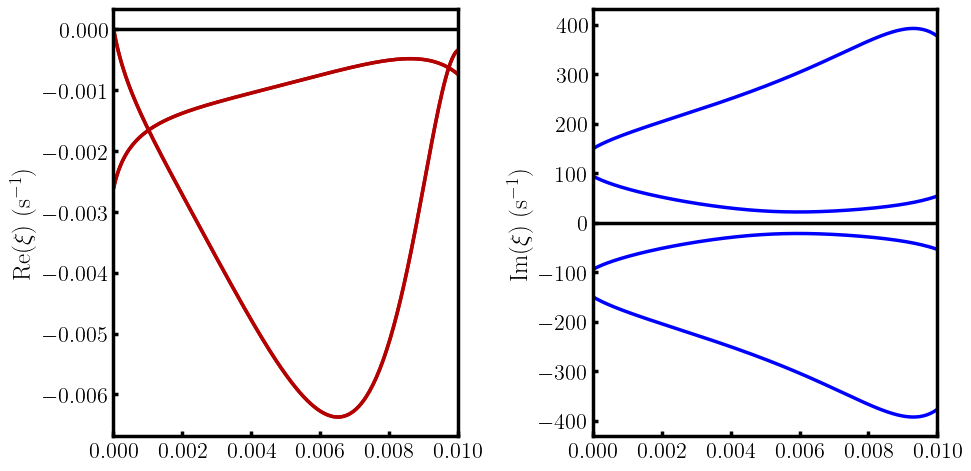

In [4]:
# Plot eigenvectors separately
log_axis = False
eigval_fig, axs = plt.subplots(1,2, figsize=(10,5))

axs_flat = axs.flatten()
axs_flat[0].plot(betas, real_eigvals, color=colorReal, linewidth=l_width)
axs_flat[1].plot(betas, imag_eigvals, color=colorImag, linewidth=l_width)
axs_flat[0].set_yscale('linear')
axs_flat[1].set_yscale('linear')
axs_flat[0].set(xlim=(betas[0],betas[-1]))
axs_flat[1].set(xlim=(betas[0],betas[-1]))
dynplot.show_standard_axes(axs_flat[0], None, xlabel=None, ylabel=r"$\Re(\xi)$ (s$^{-1}$)" if not normalise else r"$\Re(\bar{\xi})$", show_zero_line=True)
dynplot.show_standard_axes(axs_flat[1], None, xlabel=None, ylabel=r"$\Im(\xi)$ (s$^{-1}$)" if not normalise else r"$\Im(\bar{\xi})$", show_zero_line=True)
    
ftype = ".pdf"
save_fname = str(fname_preamble) + f"/{runID}_eigval_normalise{normalise}" + ftype
eigval_fig.savefig(save_fname, bbox_inches="tight")

### First-order perturbation eigenvalues from Jacobian terms

In [ ]:
base_root = np.sqrt(4*kyphi*kphiy + (kyy - kphiphi)**2)

# Unperturbed eigenvalues (positive only)
eigval_unp1 = 1/np.sqrt(2)*np.sqrt(kyy + kphiphi - base_root, dtype=np.complex128)
eigval_unp3 = 1/np.sqrt(2)*np.sqrt(kyy + kphiphi + base_root, dtype=np.complex128)

mix = kyphi*muphiy + kphiy*muyphi
diag_diff = (kyy - kphiphi)*(muyy - muphiphi)

real_eigval1 = 1/4 * (muyy + muphiphi - (2*mix + diag_diff)/base_root)
real_eigval3 = 1/4 * (muyy + muphiphi + (2*mix + diag_diff)/base_root)

eigval1 = -eigval_unp1 + 1/4 * (muyy + muphiphi - (2*mix + diag_diff)/base_root)
eigval2 = eigval_unp1 + 1/4 * (muyy + muphiphi - (2*mix + diag_diff)/base_root)
eigval3 = -eigval_unp3 + 1/4 * (muyy + muphiphi + (2*mix + diag_diff)/base_root)
eigval4 = eigval_unp3 + 1/4 * (muyy + muphiphi + (2*mix + diag_diff)/base_root)

cross = (2*mix + diag_diff)/base_root
print(muyy[:10])
print(muphiphi[:10])
print(cross[:10])

real_pert_eigvals = np.real(np.array([eigval1, eigval2, eigval3, eigval4]).T)
imag_pert_eigvals = np.imag(np.array([eigval1, eigval2, eigval3, eigval4]).T)

pert_eig_fig, ax = plt.subplots(1,2, figsize=(10,5))
ax[0].plot(betas, real_pert_eigvals, color=colorReal, linewidth=l_width)
ax[1].plot(betas, imag_pert_eigvals, color=colorImag, linewidth=l_width)

# Check the analytic real part:
# ax[0].plot(betas, real_eigval1, color="green", linewidth=l_width, linestyle='--')
# ax[0].plot(betas, real_eigval3, color="green", linewidth=l_width, linestyle='--')

ax[0].set_yscale('linear')
ax[1].set_yscale('linear')
ax[0].set(xlim=(betas[0],betas[-1]))
ax[1].set(xlim=(betas[0],betas[-1]))
dynplot.show_standard_axes(ax[0], None, xlabel=None, ylabel=r"$\Re(\xi)$ (s$^{-1}$)", show_zero_line=True)
dynplot.show_standard_axes(ax[1], None, xlabel=None, ylabel=r"$\Im(\xi)$ (s$^{-1}$)", show_zero_line=True)

# ftype = ".pdf"
# save_fname = str(fname_preamble) + f"/{runID}_eigval_perturb" + ftype
# eigval_fig.savefig(save_fname, bbox_inches="tight")

In [ ]:
# print((real_eigvals[:10,:] - real_pert_eigvals[:10,:])/real_eigvals[:10,:])
# print(imag_eigvals[:10,:] - imag_pert_eigvals[:10,:])  # imaginary parts are not aligned
print(real_pert_eigvals[135:155,:])
np.argmax(real_pert_eigvals,axis=0)

### Both

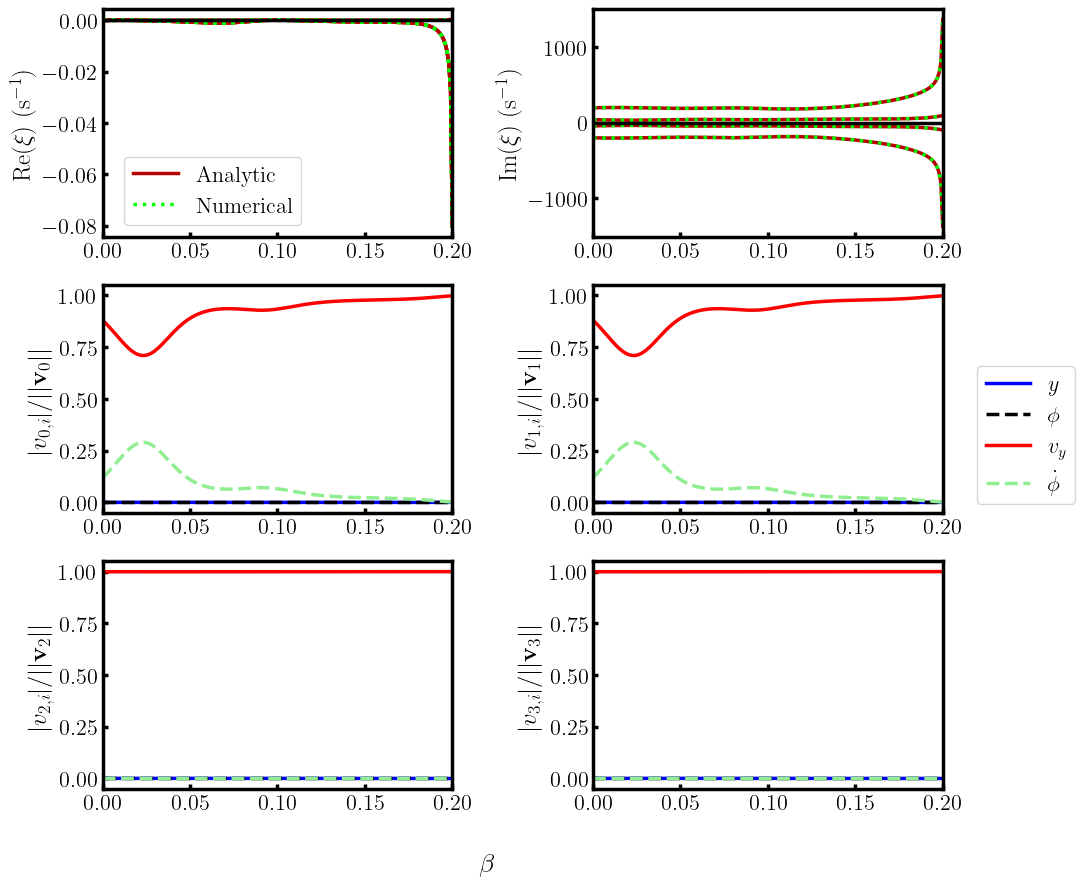

In [10]:
# Plot eigenvectors separately
log_axis = False
eigvec_fig, axs = plt.subplots(3,2, figsize=(10,9))

axs_flat = axs.flatten()
if use_perturbed:
    axs_flat[0].plot(betas, preal_eigvals, color=colorReal, linewidth=l_width)
    axs_flat[0].plot(betas, preal_eigvals[:,0], color=colorReal, linewidth=l_width, label=r"Analytic")  # for legend label
    axs_flat[1].plot(betas, pimag_eigvals, color=colorReal, linewidth=l_width)
    axs_flat[0].plot(betas, real_eigvals, color="lime", linewidth=l_width, linestyle=':')
    axs_flat[0].plot(betas, real_eigvals[:,0], color="lime", linewidth=l_width, linestyle=':', label=r"Numerical")
    axs_flat[1].plot(betas, imag_eigvals, color="lime", linewidth=l_width, linestyle=':')
    axs_flat[0].legend(loc='center right', bbox_to_anchor=(0.6,0.2))
else:
    axs_flat[0].plot(betas, real_eigvals, color=colorReal, linewidth=l_width)
    axs_flat[1].plot(betas, imag_eigvals, color=colorImag, linewidth=l_width)
axs_flat[0].set_yscale('linear')
axs_flat[1].set_yscale('linear')
axs_flat[0].set(xlim=(betas[0],betas[-1]))
axs_flat[1].set(xlim=(betas[0],betas[-1]))
dynplot.show_standard_axes(axs_flat[0], None, xlabel=None, ylabel=r"$\Re(\xi)$ (s$^{-1}$)" if not normalise else r"$\Re(\bar{\xi})$", show_zero_line=True)
dynplot.show_standard_axes(axs_flat[1], None, xlabel=None, ylabel=r"$\Im(\xi)$ (s$^{-1}$)" if not normalise else r"$\Im(\bar{\xi})$", show_zero_line=True)

axs_flat = axs_flat[2:]
# axs_flat[1], axs_flat[2] = axs_flat[2], axs_flat[1]  # switch so that degenerate eigvec magnitudes are shown in columns
for eigvec_idx, ax in enumerate(axs_flat):
    ax.plot(betas, eigvec_moduli[:,0,eigvec_idx], label=r"$y$" if not normalise else r"$\bar{y}$", color=colorY2, linewidth=l_width)
    ax.plot(betas, eigvec_moduli[:,1,eigvec_idx], label=r"$\phi$", color=colorphi2, linewidth=l_width, linestyle="--")
    ax.plot(betas, eigvec_moduli[:,2,eigvec_idx], label=r"$v_y$" if not normalise else r"$\bar{v}_y$", color=colorvY2, linewidth=l_width)
    ax.plot(betas, eigvec_moduli[:,3,eigvec_idx], label=r"$\dot{\phi}$" if not normalise else r"$\bar{\dot{\phi}}$", color=colorvphi2, linewidth=l_width, linestyle="--")

    if log_axis:
        ax.set(xlim=(betas[0],betas[-1]), ylim=(1e-9,1e1))
        ax.set_yscale('log')
    else:
        ax.set(xlim=(betas[0],betas[-1]), ylim=(-0.05,1.05))
    nd_ylabel = rf"$|v_{{{eigvec_idx},i}}|/||\mathbf{{v}}_{{{eigvec_idx}}}||$" if not normalise else rf"$|\bar{{v}}_{{{eigvec_idx},i}}|/||\bar{{\mathbf{{v}}}}_{{{eigvec_idx}}}||$"
    ax = dynplot.show_standard_axes(ax, None, xlabel=None, ylabel=nd_ylabel, show_zero_line=False)
    

eigvec_fig.supxlabel(r"$\beta$")
handles, labels = ax.get_legend_handles_labels()
leg = eigvec_fig.legend(handles, labels, loc='center right', bbox_to_anchor=(1.1,0.5))

ftype = ".pdf"
save_fname = str(fname_preamble) + f"/{runID}_eigen_normalise{normalise}" + ftype
eigvec_fig.savefig(save_fname, bbox_inches="tight")

## Quality factor

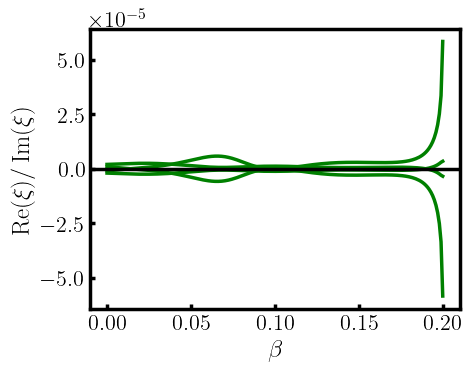

In [11]:
q_fig, q_ax = plt.subplots(1, figsize=(5,4))
q_ax.plot(betas, real_eigvals/imag_eigvals, color="green", linewidth=l_width)
ylabel = r"$\Re(\xi)/\Im(\xi)$" if not normalise else r"$\Re(\bar{\xi})/\Im(\bar{\xi})$"
dynplot.show_standard_axes(q_ax, None, xlabel=r"$\beta$", ylabel=ylabel, show_zero_line=True)

save_fname = str(fname_preamble) + f"/{runID}_quality_factor_normalise{normalise}" + ftype
q_fig.savefig(save_fname, bbox_inches="tight")

## Jacobian terms spectra

### All terms

Grouped by acceleration or angular acceleration

Can choose to calculate the Jacobian terms using Qpr derivatives or directly from the diffraction derivatives.

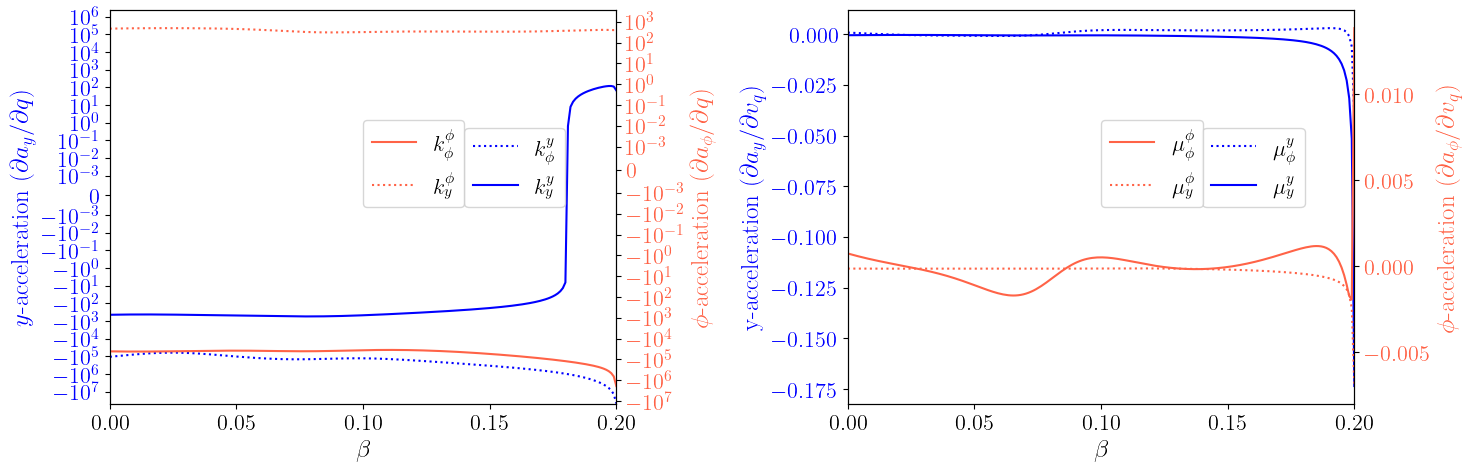

In [12]:
################
# Restoring terms
stiff_fig,(ax, ax2) = plt.subplots(1,2,figsize=(15,5))


ax.plot(betas, kyphi,  label=r"$k^y_\phi$",color=colorY,linestyle="dotted")
ax.plot(betas, kyy,    label=r"$k^y_y$",color=colorY)

ax.set_xlabel(r"$\beta$")
ay_coord_label = r"Norm. $y$-acceleration ($\partial a_y/\partial q$)" if normalise else r"$y$-acceleration ($\partial a_y/\partial q$)"
ax.set_ylabel(ay_coord_label,color=colorY)
ax.tick_params(axis='y',labelcolor=colorY)

# ax.hlines(0,0,5,"k","dashed",alpha=0.2)
t = ax.get_ylim()
# ax.axhspan(0,t[1],color='black',alpha=0.2)

ax1 = ax.twinx()
ax1.plot(betas, kphiy,  label=r"$k^\phi_y$",color=colorvphi,linestyle="dotted")
ax1.plot(betas,kphiphi,label=r"$k^\phi_\phi$",color=colorvphi)

aphi_coord_label = r"Norm. $\phi$-acceleration ($\partial a_\phi/\partial q$)" if normalise else r"$\phi$-acceleration ($\partial a_\phi/\partial q$)"
ax1.set_ylabel(aphi_coord_label,color=colorvphi)
ax1.tick_params(axis='y',labelcolor=colorvphi)


# ax.set_ylim(t)
ax.set_yscale('symlog', linthresh=1e-3)
ax1.set_yscale('symlog', linthresh=1e-3)
ax.set_xlim(betas[0],betas[-1])

# ax.set_xticks([0,1,1.45,2,3,4,5])

handles, labels = ax.get_legend_handles_labels()
handles1, labels1 = ax1.get_legend_handles_labels()
order = [0,1]
order1=[1,0]
ax.legend([handles[idx] for idx in order],[labels[idx] for idx in order],loc=(0.5+0.2,0.5))
ax1.legend([handles1[idx] for idx in order1],[labels1[idx] for idx in order1],loc=(0.5,0.5))

########################
ax2.plot(betas,muyphi, label=r"$\mu^y_\phi$", color=colorY,linestyle="dotted")
ax2.plot(betas,muyy, label=r"$\mu^y_y$",color=colorY)
ax2
ax2.set_xlabel(r"$\beta$")
ay_vel_label = r"Norm. y-acceleration ($\partial a_y/\partial v_q$)" if normalise else r"y-acceleration ($\partial a_y/\partial v_q$)"
ax2.set_ylabel(ay_vel_label, color=colorY)
ax2.tick_params(axis='y', labelcolor=colorY)

t=ax2.get_ylim()
ax2b=ax2.twinx()

ax2b.plot(betas,muphiy, label=r"$\mu^\phi_y$",color=colorvphi,linestyle="dotted")
ax2b.plot(betas,muphiphi, label=r"$\mu^\phi_\phi$", color=colorvphi)

aphi_vel_label = r"Norm. $\phi$-acceleration ($\partial a_\phi/\partial v_q$)" if normalise else r"$\phi$-acceleration ($\partial a_\phi/\partial v_q$)"
ax2b.set_ylabel(aphi_vel_label,color=colorvphi)
ax2b.tick_params(axis='y',labelcolor=colorvphi)

# # Does not correspond to 1.28%
# ax.vlines(1.4507253626813408,t[0],0,color='k',linestyle='dashed',alpha=0.2)
# ax.hlines(0,0,1.4507253626813408,color='k',linestyle='dashed',alpha=0.2)

ax2.set_ylim(t)
ax2.set_xlim(betas[0],betas[-1])

# ax.set_xticks([0,1,1.45,2,3,4,5])
 
handles, labels = ax2.get_legend_handles_labels()
handles1, labels1 = ax2b.get_legend_handles_labels()
order = [0,1]
order1=[1,0]
ax2.legend([handles[idx] for idx in order],[labels[idx] for idx in order],loc=(0.5+0.2,0.5))
ax2b.legend([handles1[idx] for idx in order1],[labels1[idx] for idx in order1],loc=(0.5,0.5))

stiff_fig.tight_layout()
ftype = ".pdf"
save_fname = str(fname_preamble) + f"/{runID}_jacobian_coefficients_normalise{normalise}" + ftype
stiff_fig.savefig(save_fname, bbox_inches="tight")

### Only restoring force/torque

In [ ]:
stiff_fig, ax = plt.subplots(1,figsize=(6,4))

kyy, kyphi, kphiy, kphiphi = restoring_coeffs.T
muyy, muyphi, muphiy, muphiphi = damping_coeffs.T

ax.plot(betas, kyy,    label=r"$\bar{k}^y_y$",color=colorY)
ax.set_xlabel(r"$\beta$")
ax.set_ylabel(r"Norm. $y$-acceleration ($\partial a_y/\partial q$)",color=colorY)
ax.tick_params(axis='y',labelcolor=colorY)

t = ax.get_ylim()
ax1 = ax.twinx()
ax1.plot(betas,kphiphi,label=r"$\bar{k}^\phi_\phi$",color=colorvphi)
ax1.set_ylabel(r"Norm. $\phi$-acceleration ($\partial a_\phi/\partial q$)",color=colorvphi)
ax1.tick_params(axis='y',labelcolor=colorvphi)

vels = [[b,0] for b in betas]
Dopplers = np.array(parameters.D1_ND(vels))
s1 = 1./Dopplers/grating.grating_pitch
c1 = np.sqrt(1 - s1**2)
w = grating.gaussian_width/L
w0_1 = 1 - np.exp(-1/(2*w*2))
w18_0 = (w/2)**2 * w0_1
ax1.plot(betas, -kyy/c1*w18_0/w0_1, 
         label=r"$-\frac{\bar{k}^y_y}{\cos\delta_1'}\frac{w^{\rightarrow 1/8}_{0\leftarrow}}{w^{\rightarrow 0}_{1\leftarrow}}$", 
         color="black")


ax.set_ylim(t)
ax.set_xlim(betas[0],betas[-1])

stiff_fig.legend(loc='center left', bbox_to_anchor=(1.0,0.5))

stiff_fig.tight_layout()
ftype = ".pdf"
save_fname = fname_preamble + f"/Dynamics/{runID}_restoring_coefficients" + ftype
# stiff_fig.savefig(save_fname, bbox_inches="tight")

grating.show_spectrum(0., "PDr", wavelength_range=[1,1.225])

## Analytic calculations

In [ ]:
# Cannot normalise Jacobian terms when calculating Routh-Hurwitz coefficients or eigen
restoring_coeffs, damping_coeffs, real_eigvals, imag_eigvals, eigvec_moduli = dynplot.generate_lsa_spectrum(grating, speed_range, I, num_points, normalise=False)
kyy, kyphi, kphiy, kphiphi = restoring_coeffs.T
muyy, muyphi, muphiy, muphiphi = damping_coeffs.T

betas = np.linspace(0,final_speed/100, num_points)

### Routh-Hurwitz stability

In [ ]:
muyy = muyy
kyphi = kyphi

a1 = -muyy - muphiphi
a2 = muyy*muphiphi - muyphi*muphiy - (kyy + kphiphi)
a3 = kyy*muphiphi + kphiphi*muyy - (kyphi*muphiy + kphiy*muyphi)
a4 = kyy*kphiphi - kyphi*kphiy

condition1 = a1
condition2 = a1*a2 - a3
condition3 = a3*condition2 - a1**2*a4
condition4 = a4

RH_fig, RH_ax = plt.subplots(1,figsize=(6,5))
RH_ax = dynplot.plot_array_on_same_axes(RH_ax, betas, condition1, linewidth=2.5, color="red", linestyle="-", label=r"Negative damping coeff")
RH_ax = dynplot.plot_array_on_same_axes(RH_ax, betas, condition2, linewidth=2.5, color="magenta", linestyle="--", label=r"Mixed 1")
RH_ax = dynplot.plot_array_on_same_axes(RH_ax, betas, condition3, linewidth=2.5, color="cyan", linestyle="--", label=r"Mixed 2")
RH_ax = dynplot.plot_array_on_same_axes(RH_ax, betas, condition4, linewidth=2.5, color="blue", linestyle="-", label=r"Restoring $\textgreater$ Coupling")
RH_ax = dynplot.show_standard_axes(RH_ax, betas, xlabel=r"$\beta$", ylabel=r"Routh-Hurwitz coefficients (arb. units)", show_zero_line=True, ax_width=2.5)
RH_fig.legend(loc='upper right')
RH_ax.set_yscale('log')

RH_fig.tight_layout()
ftype = ".pdf"
save_fname = fname_preamble + f"/Dynamics/{runID}_Routh_Hurwitz" + ftype
RH_fig.savefig(save_fname, bbox_inches="tight")

### Eigenvalues from scaled Jacobian terms

In [ ]:
scaled_eigval_fig, scaled_eigval_ax = plt.subplots(1,2,figsize=(10,4.5))
real_eigvals = []
imag_eigvals = []
for i in range(num_points):
    Jac = grating.npa.array([[0, 0, 1, 0],[0, 0, 0, 1], 
                             [kyy[i], kyphi[i], muyy[i], muyphi[i]], 
                             [kphiy[i], kphiphi[i], muphiy[i], muphiphi[i]]])
    eigvals = grating.npa.eigvals(Jac)
    real_eigvals.append(grating.npa.real(eigvals))
    imag_eigvals.append(grating.npa.imag(eigvals))
scaled_eigval_ax[0].plot(betas, grating.to_numpy(real_eigvals), color=colorReal, linewidth=l_width)
scaled_eigval_ax[1].plot(betas, grating.to_numpy(imag_eigvals), color=colorImag, linewidth=l_width)
scaled_eigval_ax[0].set_yscale('linear')
scaled_eigval_ax[1].set_yscale('linear')
scaled_eigval_ax[0].set(xlim=(betas[0],betas[-1]))
scaled_eigval_ax[1].set(xlim=(betas[0],betas[-1]))
dynplot.show_standard_axes(scaled_eigval_ax[0], None, xlabel=None, ylabel=r"$\Re(\xi)$ (s$^{-1}$)", show_zero_line=True)
dynplot.show_standard_axes(scaled_eigval_ax[1], None, xlabel=None, ylabel=r"$\Im(\xi)$ (s$^{-1}$)", show_zero_line=True)
scaled_eigval_fig.supxlabel(r"$\beta$")
# scaled_eigval_ax[0].set_yscale('symlog', linthresh=1e-5)
# scaled_eigval_ax[0].set_ylim(-3e-4,0.)

scaled_eigval_fig.tight_layout()
ftype = ".pdf"
save_fname = fname_preamble + f"/Dynamics/{runID}_scaled_Jacobian_eigenvalues" + ftype
scaled_eigval_fig.savefig(save_fname, bbox_inches="tight")

### Jacobian Terms width-dependence

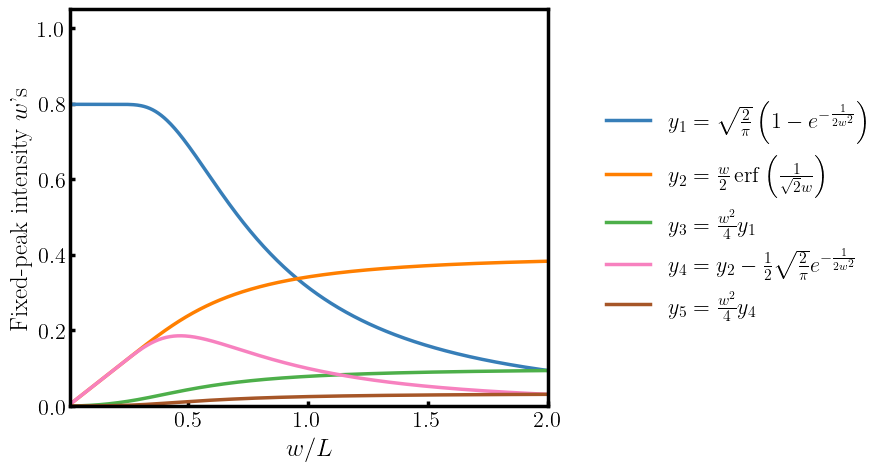

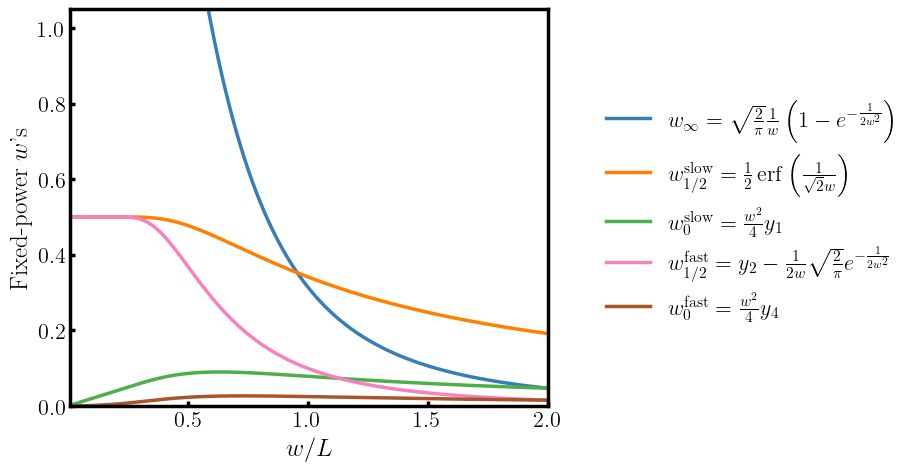

In [14]:
import numpy as np
import scipy
import matplotlib.pyplot as plt
import dynplot
import fom
from parameters import Parameters
I0, L, m, c = Parameters()

num_points = 500
bounds = (0.01, 2.)  # Width bounds in units of L
ws = np.linspace(*bounds, num_points)
rt2 = np.sqrt(2)
rt2pi = np.sqrt(2/np.pi)
expw = np.exp(-1/(2*ws**2))
erfw = scipy.special.erf(1/(ws*rt2))

CB_color_cycle = ['#377eb8', '#ff7f00', '#4daf4a',
                  '#f781bf', '#a65628', '#984ea3',
                  '#999999', '#e41a1c', '#dede00']

# Width-dependence with fixed peak-intensity
y1 = rt2pi * (1 - expw)
y2 = ws/2 * erfw
y3 = ws**2/4 * y1
y4 = y2 - rt2pi/2*expw
y5 = ws**2/4 * y4

fixed_peak_ws = [y1, y2, y3, y4, y5]
fixed_power_ws = [y/ws for y in fixed_peak_ws]

fixed_peak_labels = [r"$y_1 = \sqrt{\frac{2}{\pi}} \left(1 - e^{-\frac{1}{2w^2}}\right)$",
                     r"$y_2 = \frac{w}{2} \operatorname{erf}\left(\frac{1}{\sqrt{2}w}\right)$",
                     r"$y_3 = \frac{w^2}{4} y_1$",
                     r"$y_4 = y_2 - \frac{1}{2} \sqrt{\frac{2}{\pi}} e^{-\frac{1}{2w^2}}$",
                     r"$y_5 = \frac{w^2}{4} y_4$"]
fixed_power_labels = [r"$w_\infty = \sqrt{\frac{2}{\pi}} \frac{1}{w} \left(1 - e^{-\frac{1}{2w^2}}\right)$",
                      r"$w_{1/2}^\text{slow} = \frac{1}{2} \operatorname{erf}\left(\frac{1}{\sqrt{2}w}\right)$",
                      r"$w_{0}^\text{slow} = \frac{w^2}{4} y_1$",
                      r"$w_{1/2}^\text{fast} = y_2 - \frac{1}{2w} \sqrt{\frac{2}{\pi}} e^{-\frac{1}{2w^2}}$",
                      r"$w_{0}^\text{fast} = \frac{w^2}{4} y_4$"]

# Plotting
figsize = (6,5)
fixed_peak_fig, fixed_peak_ax = plt.subplots(1, figsize=figsize)
fixed_power_fig, fixed_power_ax = plt.subplots(1, figsize=figsize)
for i in range(5):
    fixed_peak_ax.plot(ws, fixed_peak_ws[i], color=CB_color_cycle[i], linewidth=2.5, label=fixed_peak_labels[i])
    dynplot.show_standard_axes(fixed_peak_ax, None, xlabel=r"$w/L$", ylabel=r"Fixed-peak intensity $w$'s", show_zero_line=False)
    fixed_peak_ax.set(xlim=(ws[0], ws[-1]), ylim=(0., 1.05))

    fixed_power_ax.plot(ws, fixed_power_ws[i], color=CB_color_cycle[i], linewidth=2.5, label=fixed_power_labels[i])
    dynplot.show_standard_axes(fixed_power_ax, None, xlabel=r"$w/L$", ylabel=r"Fixed-power $w$'s", show_zero_line=False)
    fixed_power_ax.set(xlim=(ws[0], ws[-1]), ylim=(0., 1.05))

fixed_peak_fig.legend(loc='center left', frameon=False, bbox_to_anchor=(1., 0.55))
fixed_power_fig.legend(loc='center left', frameon=False, bbox_to_anchor=(1., 0.55))

# ftype = ".pdf"
# save_fname = fname_preamble + f"/Dynamics/{runID}_width_dependence_{i}" + ftype
# fig.savefig(save_fname, bbox_inches="tight")

### Grating-optimum eigenvalue width dependence

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import dynplot
import fom
from parameters import Parameters
I0, L, m, c = Parameters()

num_points = 10
ws = np.linspace(0.001, 0.01, num_points)

# Real-part eigenvalues beam-width dependence
test = num_points
dim_eigmin_ws = np.zeros(num_points)
dim_eigmax_ws = np.zeros(num_points)
for i in range(test):
    grating.gaussian_width = ws[i]*L
    dim_eigmin_ws[i] = fom.FOM_uniform(grating, fom=fom.FoM_asymp, final_speed=20., goal=0.1, return_grad=False)
    dim_eigmax_ws[i] = fom.FOM_uniform(grating, fom=fom.FoM_max_eigval, final_speed=20., goal=0.1, return_grad=False)

In [ ]:
eigmin_ws = dim_eigmin_ws/np.max(np.abs(dim_eigmin_ws))  # Normalise to the maximum value
eigmax_ws = dim_eigmax_ws/np.max(np.abs(dim_eigmax_ws))  # Normalise to the maximum value

eigw_fig, eigw_ax = plt.subplots(1, figsize=(9,5))
eigw_ax.plot(ws, eigmin_ws, color="red", linewidth=2.5, label=r"$\text{minimum}[\Re(-\xi)]$")
eigw_ax.plot(ws, eigmax_ws, color="blue", linewidth=2.5, label=r"$\text{maximum}[\Re(-\xi)]$")
dynplot.show_standard_axes(eigw_ax, None, xlabel=r"$w/L$", ylabel=r"Average $\Re(-\xi)$ (norm.)", show_zero_line=True)
# eigw_ax.set(xlim=(ws[0], ws[-1]), ylim=(0., 1.05))
eigw_ax.set(xlim=(ws[0], ws[-1]))
eigw_ax.legend(loc='center left', frameon=False, bbox_to_anchor=(1., 0.55))

ftype = ".pdf"
save_fname = str(fname_preamble) + f"/{runID}_width_dependence{ws[-1]}" + ftype
eigw_fig.savefig(save_fname, bbox_inches="tight")

In [ ]:
normalise = False
start_idx = 0

if normalise:
    emin = dim_eigmin_ws / np.max(np.abs(dim_eigmin_ws))
    emax = dim_eigmax_ws / np.max(np.abs(dim_eigmax_ws))
    ylabel = r"Average $\Re(-\xi)$ (norm.)"
else:
    emin = dim_eigmin_ws
    emax = dim_eigmax_ws
    ylabel = r"Average $\Re(-\xi)$ (s$^{-1}$)"

eigw_fig, eigw_ax = plt.subplots(1, figsize=(9,5))
eigw_ax.plot(ws[start_idx:], emin[start_idx:], color="red", linewidth=2.5, label=r"$\text{minimum}[\Re(-\xi)]$")
eigw_ax.plot(ws[start_idx:], emax[start_idx:], color="blue", linewidth=2.5, label=r"$\text{maximum}[\Re(-\xi)]$")
dynplot.show_standard_axes(eigw_ax, None, xlabel=r"$w/L$", ylabel=ylabel, show_zero_line=True)
eigw_ax.set(xlim=(ws[start_idx], ws[-1]), ylim=(1e-6, 2.5e-4))
eigw_ax.set_yscale('log')
eigw_ax.legend(loc='center left', frameon=False, bbox_to_anchor=(1., 0.55))

max_arg = np.argmax(emin)
print(max_arg)
print(ws[max_arg])

ftype = ".pdf"
save_fname = str(fname_preamble) + f"/{runID}_width_dependence{ws[-1]}_normalise{normalise}" + ftype
eigw_fig.savefig(save_fname, bbox_inches="tight")

In [ ]:
# wkyy = fixed_power_ws[0]
# wkyp = fixed_power_ws[1]
# wkpp = fixed_power_ws[2] 
# wkpy = fixed_power_ws[3]
# wmpp = fixed_power_ws[4]
# wmyy = wkyp
# wmyp = wkpp
# wmpy = wkpp

# base_root = np.sqrt(4*wkyp*wkpy + (wkyy - wkpp)**2)
# mix = wkyp*wmpy + wkpy*wmyp
# diag_diff = (wkyy - wkpp)*(wmyy - wmpp)

# real_eig12_ws = wmyy + wmpp - (2*mix + diag_diff)/base_root
# real_eig34_ws = wmyy + wmpp + (2*mix + diag_diff)/base_root

# fixed_power_ax.plot(ws, real_eig12_ws, color="red", linestyle="--", linewidth=2.5, label=r"$\Re(\xi_{1,2})$")
# fixed_power_ax.plot(ws, real_eig34_ws, color="black", linestyle="--", linewidth=2.5, label=r"$\Re(\xi_{3,4})$")
# # fixed_power_ax.plot(ws, ws*real_eig12_ws, color="red", linestyle="--", linewidth=2.5, label=r"$t_f\Re(\xi_{1,2})$")
# # fixed_power_ax.plot(ws, ws*real_eig34_ws, color="black", linestyle="--", linewidth=2.5, label=r"$t_f\Re(\xi_{3,4})$")

### Doppler factor

0.8232664126756468


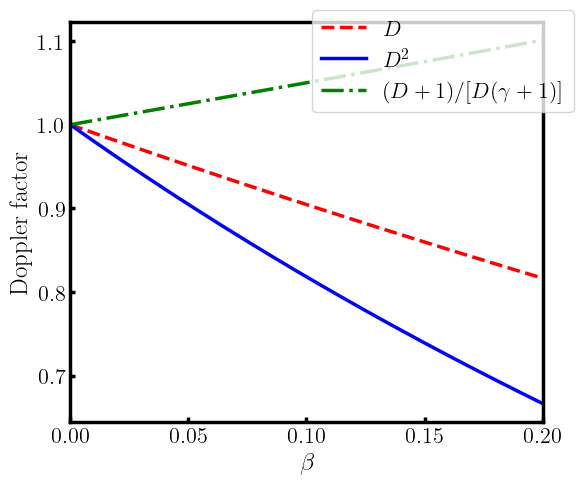

In [6]:
import dynplot

final_speed = 20.
num_points = 200
betas = np.linspace(0,final_speed/100, num_points)
vels = [[b,0] for b in betas]
Dopplers = np.array(parameters.D1_ND(vels))
gammas = np.array(parameters.gamma_ND(vels))
Dsq = Dopplers**2
D_plus_1 = (Dopplers+1)/(Dopplers*(gammas+1))
fig, ax = plt.subplots(1, figsize=(6,5))
ax = dynplot.plot_array_on_same_axes(ax, betas, Dopplers, linewidth=2.5, color="red", linestyle="--", label=r"$D$")
ax = dynplot.plot_array_on_same_axes(ax, betas, Dsq, linewidth=2.5, color="blue", linestyle="-", label=r"$D^2$")
ax = dynplot.plot_array_on_same_axes(ax, betas, D_plus_1, linewidth=2.5, color="green", linestyle="-.", label=r"$(D+1)/[D(\gamma+1)]$")
ax = dynplot.show_standard_axes(ax, betas, xlabel=r"$\beta$", ylabel=r"Doppler factor", show_zero_line=False, ax_width=2.5)
fig.legend(loc='upper right')

print(np.average(Dsq))

### Calculate grating pitch corresponding to a certain angle before first-order cutoff

In [5]:
final_speed = 20.
angle_max = 0.01*np.pi/180
wavelength_max = 1/parameters.D1_ND([final_speed/100.,0.])

pitch_min = wavelength_max/(1 - np.sin(angle_max))
print(pitch_min)

1.224958667009905
